


# Tópicos Especiais: Machine Learning
### **Aula Prática:** Classificação
### **Dataset:** Titanic

1) Seleção de Dados

1.1 Aquisição de Dados

In [ ]:
# prompt: Use a biblioteca pandas, importar usando a propria bibliotera o dataset Titanic

import pandas as pd

# Load the Titanic dataset directly from seaborn
titanic = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")

# Display the first few rows of the DataFrame
print(titanic.head())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


1.2 Visualização do dataset

In [ ]:
# Descrição das variáveis
print(titanic.info())

# Distribuição das variáveis numéricas
print(titanic.describe())

# Distribuição das variáveis categóricas
for col in titanic.select_dtypes(include=['object']):
  print(f"\n--- Variável: {col} ---")
  print(titanic[col].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB
None
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000

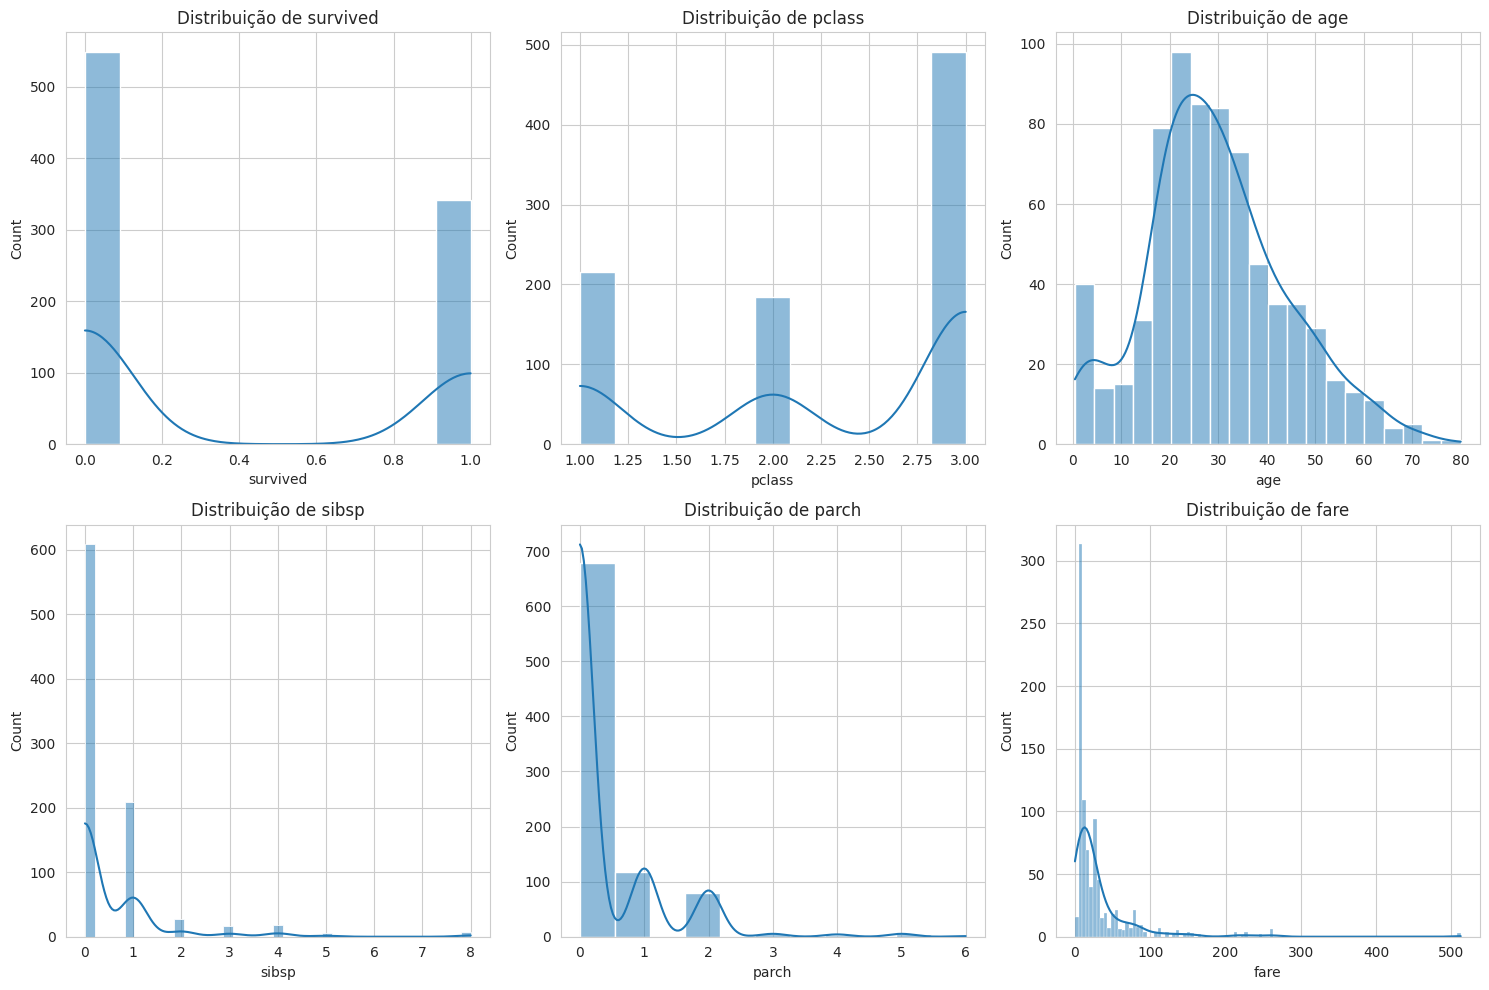

In [ ]:
# prompt: Visualizar o dataset visualmente por gráficos de distribuição. Gráficos pequenos e em grade

import matplotlib.pyplot as plt
import seaborn as sns

# Define o estilo dos gráficos
sns.set_style("whitegrid")

# Cria uma lista com os nomes das colunas numéricas
numerical_cols = titanic.select_dtypes(include=['number']).columns.tolist()

# Calcula o número de linhas e colunas para a grade de gráficos
n_rows = (len(numerical_cols) + 2) // 3  # Ajusta para 3 colunas, arredondando para cima
n_cols = min(len(numerical_cols), 3)


# Plota os gráficos de distribuição em uma grade
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5 * n_rows))

for i, col in enumerate(numerical_cols):
  row = i // n_cols
  col_idx = i % n_cols
  sns.histplot(data=titanic, x=col, kde=True, ax=axes[row, col_idx])
  axes[row, col_idx].set_title(f"Distribuição de {col}")


# Remove os subplots vazios, se houver
for i in range(len(numerical_cols), n_rows * n_cols):
  row = i // n_cols
  col_idx = i % n_cols
  fig.delaxes(axes[row, col_idx])

plt.tight_layout()
plt.show()

In [ ]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


1.3 Selecionando os atributos

In [ ]:
# prompt: Crie um novo dataset selecionando apenas as variaveis: survived, pclass, sex, age,sibsp, parch, fare, embarked, deck

# Cria um novo DataFrame com as colunas selecionadas
titanic_selected = titanic[['survived', 'pclass', 'age', 'fare', 'embarked', 'deck','alone','adult_male']]

# Exibe as primeiras linhas do novo DataFrame
print(titanic_selected.head())

   survived  pclass   age     fare embarked deck  alone  adult_male
0         0       3  22.0   7.2500        S  NaN  False        True
1         1       1  38.0  71.2833        C    C  False       False
2         1       3  26.0   7.9250        S  NaN   True       False
3         1       1  35.0  53.1000        S    C  False       False
4         0       3  35.0   8.0500        S  NaN   True        True


2) Pré-Processamento dos Dados

In [ ]:
# prompt: Quero uma relação das variáveis e seus valores ausentes

# Display missing values for each variable
print(titanic_selected.isnull().sum())

survived        0
pclass          0
age           177
fare            0
embarked        2
deck          688
alone           0
adult_male      0
dtype: int64


2.1 Substituir valores nulos em **age** para a média de idade do atibuto **adult_male**

In [ ]:
# prompt: Crie uma nova variavel que substitua os valores nulos de 'age' pela média das idades relacionadas a 'pclass'

# Group data by 'pclass' and calculate the mean age for each class
mean_age_by_pclass = titanic.groupby('adult_male')['age'].mean()

# Fill NaN values in 'age' column based on the mean age of their respective 'pclass'
titanic_selected['age_null_by_adult_male'] = titanic.apply(lambda row: mean_age_by_pclass[row['adult_male']] if pd.isnull(row['age']) else row['age'], axis=1)

/tmp/ipython-input-2471421519.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  titanic_selected['age_null_by_adult_male'] = titanic.apply(lambda row: mean_age_by_pclass[row['adult_male']] if pd.isnull(row['age']) else row['age'], axis=1)


In [ ]:
titanic_selected.head()

,survived,pclass,age,fare,embarked,deck,alone,adult_male,age_null_by_adult_male
0,0,3,22.0,7.2500,S,NaN,False,True,22.0
1,1,1,38.0,71.2833,C,C,False,False,38.0
2,1,3,26.0,7.9250,S,NaN,True,False,26.0
3,1,1,35.0,53.1000,S,C,False,False,35.0
4,0,3,35.0,8.0500,S,NaN,True,True,35.0


2.2 Criar nova variável substituindo valores nulos do atributo **'deck'** pelo valor ***'ND'***

In [ ]:
# prompt: criar nova variável substituindo valores nulos do atributo 'deck' pelo valor 'ND'

# Replace null values in the 'deck' attribute with 'ND'
titanic_selected['deck'] = titanic_selected['deck'].fillna('ND')
titanic_selected.head()

/tmp/ipython-input-1451273944.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  titanic_selected['deck'] = titanic_selected['deck'].fillna('ND')


,survived,pclass,age,fare,embarked,deck,alone,adult_male,age_null_by_adult_male
0,0,3,22.0,7.2500,S,ND,False,True,22.0
1,1,1,38.0,71.2833,C,C,False,False,38.0
2,1,3,26.0,7.9250,S,ND,True,False,26.0
3,1,1,35.0,53.1000,S,C,False,False,35.0
4,0,3,35.0,8.0500,S,ND,True,True,35.0


2.3 Reselecionando atributos

In [ ]:
titanic_selected = titanic_selected[['survived', 'pclass', 'age_null_by_adult_male', 'fare', 'embarked', 'deck','alone','adult_male']]
titanic_selected.head()

,survived,pclass,age_null_by_adult_male,fare,embarked,deck,alone,adult_male
0,0,3,22.0,7.2500,S,ND,False,True
1,1,1,38.0,71.2833,C,C,False,False
2,1,3,26.0,7.9250,S,ND,True,False
3,1,1,35.0,53.1000,S,C,False,False
4,0,3,35.0,8.0500,S,ND,True,True


3) Transformação dos Dados

3.1 Converter variáveis categoricas para númericas

Dataframe ***titatic***

In [ ]:
# prompt: Com o dataset titanic, converta as variaveis categoricas para numéricas usando a codificação LabelEncoder

from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Define the categorical columns to encode
categorical_cols = ['sex', 'embarked', 'alone', 'class', 'who', 'deck', 'embark_town','alone','alive']

# Loop through the categorical columns and apply Label Encoding
for col in categorical_cols:
    titanic[col] = label_encoder.fit_transform(titanic[col])

# Display the first few rows of the DataFrame to verify the changes
print(titanic.head())
print(titanic.info())

   survived  pclass  sex   age  sibsp  parch     fare  embarked  class  who  \
0         0       3    1  22.0      1      0   7.2500         2      2    1   
1         1       1    0  38.0      1      0  71.2833         0      0    2   
2         1       3    0  26.0      0      0   7.9250         2      2    2   
3         1       1    0  35.0      1      0  53.1000         2      0    2   
4         0       3    1  35.0      0      0   8.0500         2      2    1   

   adult_male  deck  embark_town  alive  alone  
0        True     7            2      0      0  
1       False     2            0      1      0  
2       False     7            2      1      1  
3       False     2            2      1      0  
4        True     7            2      0      1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  


In [ ]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,7,2,0,0
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,2,0,1,0
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,7,2,1,1
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,2,1,0
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,7,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,2,1,1,True,7,2,0,1
887,1,1,0,19.0,0,0,30.0000,2,0,2,False,1,2,1,1
888,0,3,0,NaN,1,2,23.4500,2,2,2,False,7,2,0,0
889,1,1,1,26.0,0,0,30.0000,0,0,1,True,2,0,1,1


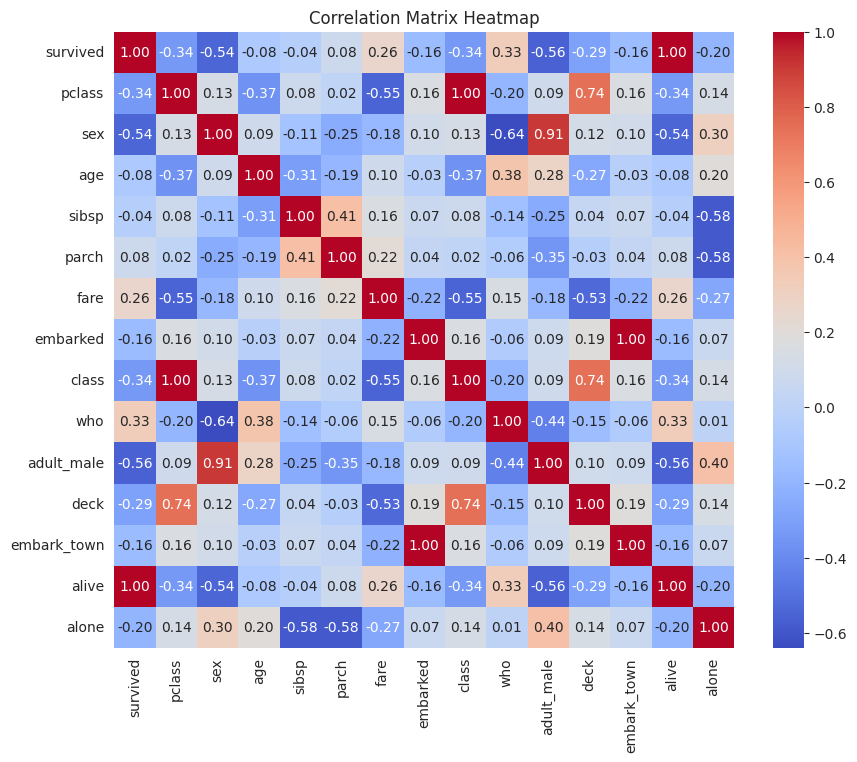

In [ ]:
# prompt: matriz de correlação com mapa de calor dos atributos do dataframe titanic, na proporção

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = titanic.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

Dataframe **titanic_selected**

In [ ]:
# prompt: Com o dataset titanic_selected, converta as variaveis deck, embarked para numéricas

# Convert 'deck' and 'embarked' to numerical using Label Encoding
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in ['deck', 'embarked']:
    titanic_selected[column] = label_encoder.fit_transform(titanic_selected[column].astype(str))

print(titanic_selected.head())
print(titanic_selected.info())

   survived  pclass  age_null_by_adult_male     fare  embarked  deck  alone  \
0         0       3                    22.0   7.2500         2     7  False   
1         1       1                    38.0  71.2833         0     2  False   
2         1       3                    26.0   7.9250         2     7   True   
3         1       1                    35.0  53.1000         2     2  False   
4         0       3                    35.0   8.0500         2     7   True   

   adult_male  
0        True  
1       False  
2       False  
3       False  
4        True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   survived                891 non-null    int64  
 1   pclass                  891 non-null    int64  
 2   age_null_by_adult_male  891 non-null    float64
 3   fare                    891 non-null    float64
 4   em

4) Mineração dos Dados ou Data Mining

4.1 Dividir as amostras em Treino, Validação e Teste

In [ ]:
# prompt: Divida o dataset em Treino, validação e teste

# 4) Mineração dos Dados ou Data Mining
# 4.1 Dividir as amostras em Treino, Validação e Teste

from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = titanic_selected.drop('survived', axis=1)
y = titanic_selected['survived']

# Split data into training and temporary sets (80% train, 20% temp)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split temporary set into validation and test sets (50% validation, 50% test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the shapes of the resulting sets to verify the split
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 7)
y_train shape: (712,)
X_val shape: (89, 7)
y_val shape: (89,)
X_test shape: (90, 7)
y_test shape: (90,)


4.2 Seleção e Treinamento da Técnica ML de Classificação

In [ ]:
# prompt: Treine um modelo de Árvore de Decisão para classificar a variavel survived

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters here
dt_classifier.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_val = dt_classifier.predict(X_val)

# Evaluate the model on the validation set
accuracy_val = accuracy_score(y_val, y_pred_val)
print(f"Decision Tree Accuracy on validation set: {accuracy_val}")

#Now you can use the trained model to predict on the test set (X_test)
y_pred_test = dt_classifier.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Decision Tree Accuracy on test set: {accuracy_test}")

Decision Tree Accuracy on validation set: 0.7865168539325843
Decision Tree Accuracy on test set: 0.7888888888888889


- Análise de Fator de Importância

/tmp/ipython-input-589142339.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette="viridis")


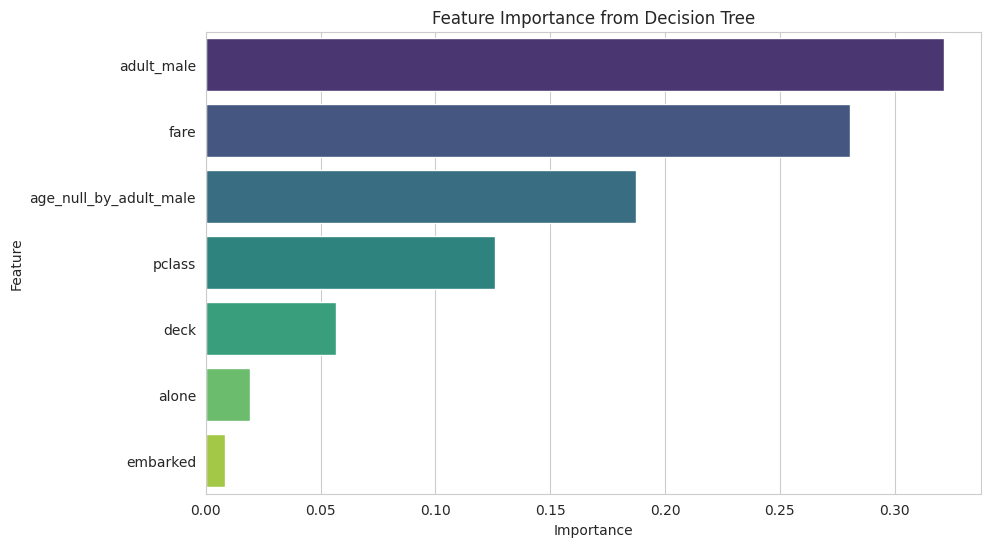

In [ ]:
# prompt: crie um gráfico com o fator de importancia entre as variáveis do dataset titanic_selected usando a árvore de decisão

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

# ... (Your existing code) ...

# 4.2 Seleção e Treinamento da Técnica ML de Classificação
# ... (Your existing code) ...


# Feature Importance from Decision Tree
feature_importances = dt_classifier.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette="viridis")
plt.title('Feature Importance from Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
# prompt: Treine um modelo de Random Forest para classificar a variavel survived

from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)  # You can adjust hyperparameters here
rf_classifier.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_val = rf_classifier.predict(X_val)

# Evaluate the model on the validation set
accuracy_val = accuracy_score(y_val, y_pred_val)
print(f"Random Forest Accuracy on validation set: {accuracy_val}")

#Now you can use the trained model to predict on the test set (X_test)
y_pred_test = rf_classifier.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Random Forest Accuracy on test set: {accuracy_test}")

Random Forest Accuracy on validation set: 0.8426966292134831
Random Forest Accuracy on test set: 0.8


In [ ]:
# prompt: Treine um modelo de AdaBoost para classificar a variavel survived

from sklearn.ensemble import AdaBoostClassifier

# Initialize and train the AdaBoost Classifier
ada_classifier = AdaBoostClassifier(random_state=42)  # You can adjust hyperparameters here
ada_classifier.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_val = ada_classifier.predict(X_val)

# Evaluate the model on the validation set
accuracy_val = accuracy_score(y_val, y_pred_val)
print(f"AdaBoost Accuracy on validation set: {accuracy_val}")

# Now you can use the trained model to predict on the test set (X_test)
y_pred_test = ada_classifier.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"AdaBoost Accuracy on test set: {accuracy_test}")

AdaBoost Accuracy on validation set: 0.8539325842696629
AdaBoost Accuracy on test set: 0.7777777777777778


In [ ]:
# prompt: Treine um modelo de GradientBoost para classificar a variavel survived

from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train the Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(random_state=42)  # You can adjust hyperparameters here
gb_classifier.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_val = gb_classifier.predict(X_val)

# Evaluate the model on the validation set
accuracy_val = accuracy_score(y_val, y_pred_val)
print(f"Gradient Boosting Accuracy on validation set: {accuracy_val}")

# Now you can use the trained model to predict on the test set (X_test)
y_pred_test = gb_classifier.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Gradient Boosting Accuracy on test set: {accuracy_test}")

Gradient Boosting Accuracy on validation set: 0.8651685393258427
Gradient Boosting Accuracy on test set: 0.7777777777777778


5) Visualização dos Resultados

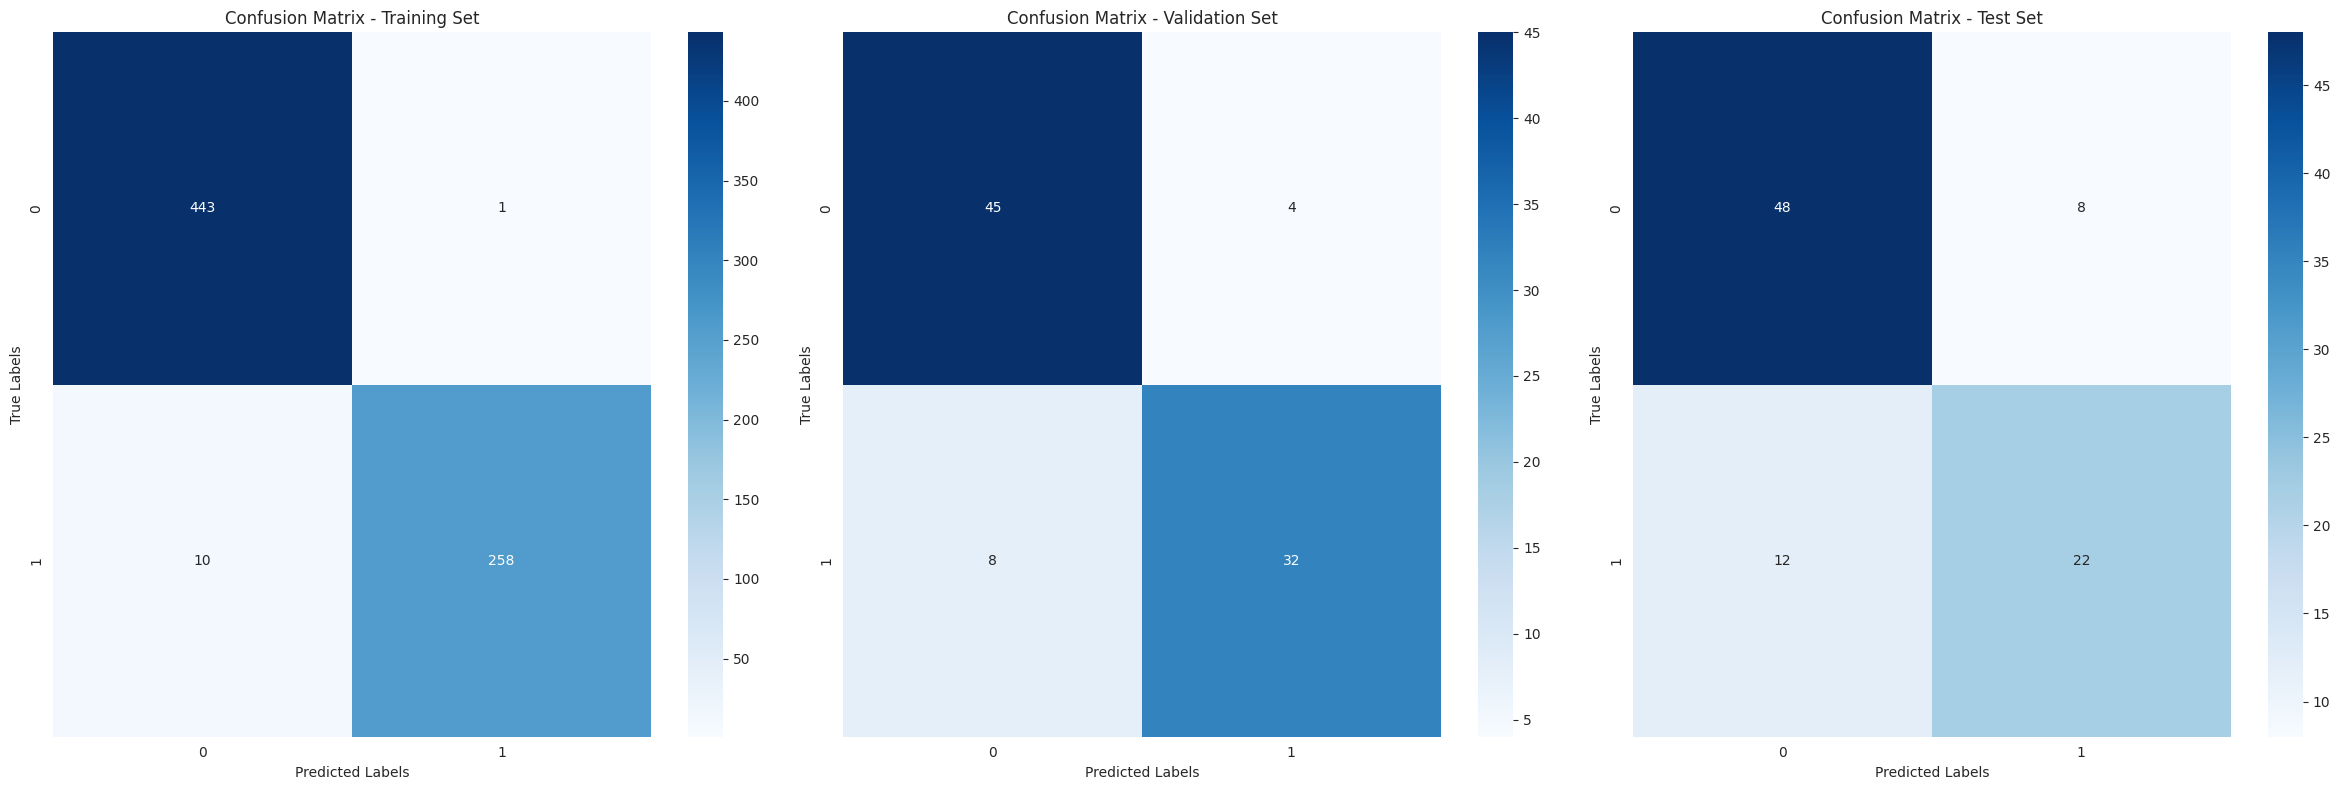

In [ ]:
# prompt: Crie uma matriz de confusão para os resultados de treino, validação e teste. Quero gráficos com proporção 8x8

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on training set
y_pred_train = dt_classifier.predict(X_train)

# Create confusion matrices
cm_train = confusion_matrix(y_train, y_pred_train)
cm_val = confusion_matrix(y_val, y_pred_val)
cm_test = confusion_matrix(y_test, y_pred_test)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Plot confusion matrix for training set
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix - Training Set")
axes[0].set_xlabel("Predicted Labels")
axes[0].set_ylabel("True Labels")

# Plot confusion matrix for validation set
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix - Validation Set")
axes[1].set_xlabel("Predicted Labels")
axes[1].set_ylabel("True Labels")


# Plot confusion matrix for test set
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Confusion Matrix - Test Set")
axes[2].set_xlabel("Predicted Labels")
axes[2].set_ylabel("True Labels")

plt.tight_layout()
plt.show()

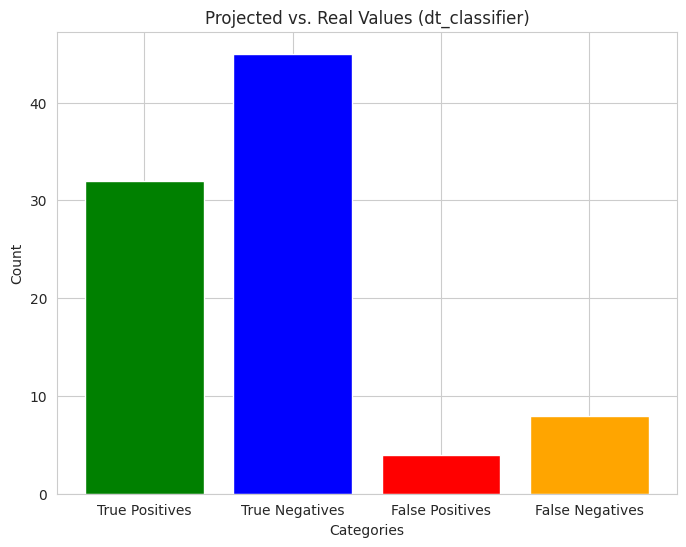

In [ ]:
# prompt: gráfico de barras para o projetado versus real (dt_classifier)

import matplotlib.pyplot as plt

# Assuming you have y_val (true values) and y_pred_val (predicted values) from your Decision Tree model.
# Replace these with your actual data if needed.

# Example data (replace with your actual y_val and y_pred_val):
#y_val = [0, 1, 0, 1, 0, 1, 0, 1]  # True values
#y_pred_val = [0, 0, 1, 1, 0, 0, 1, 1]  # Predicted values

# Calculate the counts of each class
true_positives = sum((y_val == 1) & (y_pred_val == 1))
true_negatives = sum((y_val == 0) & (y_pred_val == 0))
false_positives = sum((y_val == 0) & (y_pred_val == 1))
false_negatives = sum((y_val == 1) & (y_pred_val == 0))


# Create a bar chart for projected vs. real values
categories = ['True Positives', 'True Negatives', 'False Positives', 'False Negatives']
values = [true_positives, true_negatives, false_positives, false_negatives]

plt.figure(figsize=(8, 6))
plt.bar(categories, values, color=['green', 'blue', 'red', 'orange'])
plt.title('Projected vs. Real Values (dt_classifier)')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.show()